# 09 — Évaluation DistilBERT V2

Rechargement des modèles sauvegardés et évaluation sur le même split test. Aucun réentraînement.

Les métriques mesurent l’accord avec les pseudo-labels GPT-OSS 20B.

In [1]:
from pathlib import Path
import os, time, zipfile, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    precision_recall_fscore_support,
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


c:\Users\wiame.bourass\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 1. Racine du projet

In [2]:
cwd = Path.cwd()

if (cwd / "data").exists() and (cwd / "notebooks").exists():
    ROOT = cwd
elif cwd.name.lower() == "notebooks":
    ROOT = cwd.parent
else:
    ROOT = cwd.parent

print("Répertoire courant :", cwd)
print("Racine du projet    :", ROOT)


Répertoire courant : c:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first\notebooks
Racine du projet    : c:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first


## 2. Chemins

In [3]:
zip_path = ROOT / "artifacts" / "sephora_absa_student_v2.zip"

run_dir = (
    ROOT
    / "data"
    / "interim"
    / "test_2000_gpt_oss_20b_batch4_chunks200_v2"
)

sample_path = run_dir / "sample_2000.parquet"
pairs_path = run_dir / "pairs.parquet"

for name, path in {
    "ZIP": zip_path,
    "Sample": sample_path,
    "Pairs": pairs_path,
}.items():
    print(f"{name:7} -> {path}")
    print("Existe :", path.exists())
    print()

assert zip_path.exists(), f"ZIP introuvable : {zip_path}"
assert sample_path.exists(), f"Sample introuvable : {sample_path}"
assert pairs_path.exists(), f"Pairs introuvable : {pairs_path}"


ZIP     -> c:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first\artifacts\sephora_absa_student_v2.zip
Existe : True

Sample  -> c:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first\data\interim\test_2000_gpt_oss_20b_batch4_chunks200_v2\sample_2000.parquet
Existe : True

Pairs   -> c:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first\data\interim\test_2000_gpt_oss_20b_batch4_chunks200_v2\pairs.parquet
Existe : True



## 3. Extraction des modèles

In [4]:
EXTRACT_DIR = ROOT / "artifacts" / "student_v2_artifacts"
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extraction :", EXTRACT_DIR)


Extraction : c:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first\artifacts\student_v2_artifacts


In [5]:
def find_path(name, is_dir=False):
    for root, dirs, fs in os.walk(EXTRACT_DIR):
        if is_dir and name in dirs:
            return Path(root) / name
        if not is_dir and name in fs:
            return Path(root) / name
    return None

ASPECT_MODEL_DIR = find_path("student_aspect_distilbert_v2", is_dir=True)
SENT_MODEL_DIR = find_path("student_sentiment_distilbert_v2", is_dir=True)
THRESHOLDS_CSV = find_path("aspect_thresholds_v2.csv")
COMPARE_ASPECT_CSV = find_path("comparison_aspect_v1_v2.csv")
COMPARE_SENT_CSV = find_path("comparison_sentiment_v1_v2.csv")

assert ASPECT_MODEL_DIR is not None
assert SENT_MODEL_DIR is not None
assert THRESHOLDS_CSV is not None

print("Aspect model :", ASPECT_MODEL_DIR)
print("Sent model   :", SENT_MODEL_DIR)
print("Thresholds   :", THRESHOLDS_CSV)


Aspect model : c:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first\artifacts\student_v2_artifacts\content\student_aspect_distilbert_v2
Sent model   : c:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first\artifacts\student_v2_artifacts\content\student_sentiment_distilbert_v2
Thresholds   : c:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first\artifacts\student_v2_artifacts\content\aspect_thresholds_v2.csv


## 4. Données

In [6]:
sample = pd.read_parquet(sample_path)
pairs = pd.read_parquet(pairs_path)

ASPECTS = [
    "efficacy_results",
    "hydration_dryness",
    "texture_finish",
    "irritation_sensitivity",
    "acne_breakouts",
    "fragrance_smell",
    "application_absorption",
    "packaging",
    "price_value",
]

print("Segments :", len(sample))
print("Reviews  :", sample["review_id"].nunique())
print("Pairs    :", len(pairs))
display(pairs["aspect_id"].value_counts().to_frame("n"))


Segments : 2000
Reviews  : 1995
Pairs    : 1449


,n
aspect_id,
efficacy_results,419
texture_finish,270
hydration_dryness,195
acne_breakouts,130
fragrance_smell,129
irritation_sensitivity,108
price_value,84
application_absorption,66
packaging,48


## 5. Split train / validation / test

In [7]:
groups = sample["review_id"].astype(str)

g1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_val_idx, test_idx = next(g1.split(sample, groups=groups))

train_val = sample.iloc[train_val_idx].copy()
test_sample = sample.iloc[test_idx].copy()

g2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=SEED + 1)
tr_rel, va_rel = next(
    g2.split(train_val, groups=train_val["review_id"].astype(str))
)

train_sample = train_val.iloc[tr_rel].copy()
val_sample = train_val.iloc[va_rel].copy()

print("Train :", len(train_sample))
print("Val   :", len(val_sample))
print("Test  :", len(test_sample))


Train : 1399
Val   : 301
Test  : 300


# A — Aspects

In [8]:
segment_aspects = (
    pairs.groupby("segment_id")["aspect_id"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .to_dict()
)

def make_multilabel_matrix(df):
    y = np.zeros((len(df), len(ASPECTS)), dtype=int)
    for row_idx, segment_id in enumerate(df["segment_id"]):
        for aspect in segment_aspects.get(segment_id, []):
            if aspect in ASPECTS:
                y[row_idx, ASPECTS.index(aspect)] = 1
    return y

y_true_aspect = make_multilabel_matrix(test_sample)
print("Shape :", y_true_aspect.shape)
print("Labels positifs :", y_true_aspect.sum())


Shape : (300, 9)
Labels positifs : 204


In [9]:
threshold_df = pd.read_csv(THRESHOLDS_CSV)
threshold_map = dict(zip(threshold_df["aspect_id"], threshold_df["best_threshold"]))
thresholds = np.array([threshold_map[a] for a in ASPECTS])
display(threshold_df)


,aspect_id,best_threshold,val_f1,val_support_positive
0,efficacy_results,0.55,0.544379,76
1,hydration_dryness,0.80,0.688525,37
2,texture_finish,0.50,0.516129,43
3,irritation_sensitivity,0.75,0.666667,17
4,acne_breakouts,0.75,0.750000,17
5,fragrance_smell,0.60,0.972973,19
6,application_absorption,0.85,0.545455,8
7,packaging,0.55,0.533333,8
8,price_value,0.75,0.869565,13


In [11]:
aspect_tokenizer = AutoTokenizer.from_pretrained(ASPECT_MODEL_DIR)
aspect_model = AutoModelForSequenceClassification.from_pretrained(
    ASPECT_MODEL_DIR
).to(DEVICE)
aspect_model.eval()

texts = test_sample["segment_text"].astype(str).tolist()
BATCH_SIZE = 32
all_probs = []

for start in range(0, len(texts), BATCH_SIZE):
    batch_texts = texts[start:start+BATCH_SIZE]
    enc = aspect_tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=160,
        return_tensors="pt",
        return_token_type_ids=False,
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        logits = aspect_model(**enc).logits

    all_probs.append(torch.sigmoid(logits).cpu().numpy())

y_prob_aspect = np.vstack(all_probs)
y_pred_aspect = (y_prob_aspect >= thresholds[None, :]).astype(int)

print("Predictions :", y_pred_aspect.shape)


Predictions : (300, 9)


## A1. Métriques globales

In [12]:
p_micro, r_micro, f1_micro, _ = precision_recall_fscore_support(
    y_true_aspect, y_pred_aspect, average="micro", zero_division=0
)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true_aspect, y_pred_aspect, average="macro", zero_division=0
)
exact_match = np.mean(np.all(y_true_aspect == y_pred_aspect, axis=1))

aspect_global = pd.DataFrame({
    "metric": [
        "precision_micro","recall_micro","f1_micro",
        "precision_macro","recall_macro","f1_macro","exact_match"
    ],
    "value": [
        p_micro,r_micro,f1_micro,
        p_macro,r_macro,f1_macro,exact_match
    ],
})

display(aspect_global)


,metric,value
0,precision_micro,0.551331
1,recall_micro,0.710784
2,f1_micro,0.620985
3,precision_macro,0.689907
4,recall_macro,0.678770
5,f1_macro,0.643295
6,exact_match,0.563333


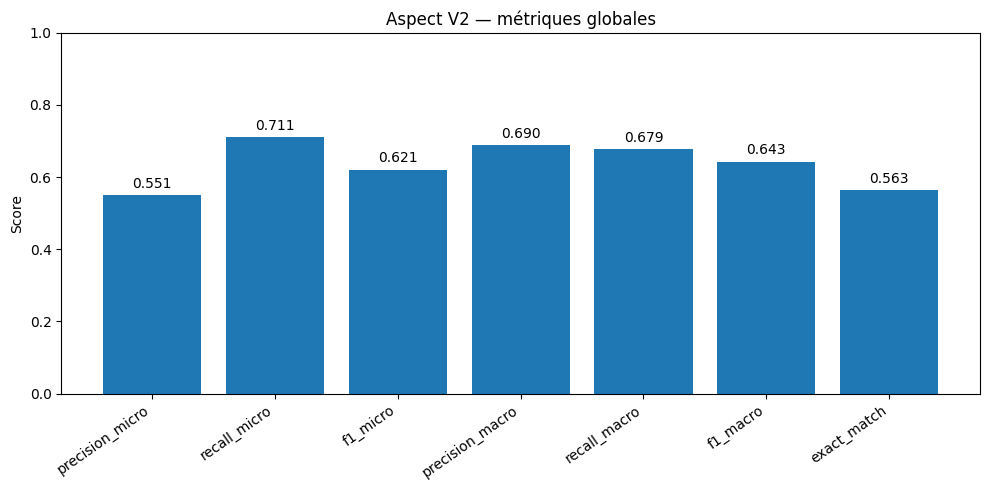

In [13]:
plt.figure(figsize=(10,5))
plt.bar(aspect_global["metric"], aspect_global["value"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Aspect V2 — métriques globales")
plt.xticks(rotation=35, ha="right")
for i, v in enumerate(aspect_global["value"]):
    plt.text(i, v+0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


## A2. Precision / Recall / F1 par aspect

In [14]:
rows = []

for i, aspect in enumerate(ASPECTS):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true_aspect[:,i],
        y_pred_aspect[:,i],
        average="binary",
        zero_division=0,
    )
    rows.append({
        "aspect_id": aspect,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support_positive": int(y_true_aspect[:,i].sum()),
        "threshold": thresholds[i],
    })

aspect_per_class = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(aspect_per_class)


,aspect_id,precision,recall,f1,support_positive,threshold
5,fragrance_smell,0.894737,1.000000,0.944444,17,0.60
8,price_value,0.900000,0.818182,0.857143,11,0.75
4,acne_breakouts,0.944444,0.739130,0.829268,23,0.75
1,hydration_dryness,0.653846,0.708333,0.680000,24,0.80
7,packaging,0.555556,0.833333,0.666667,6,0.55
2,texture_finish,0.435294,0.822222,0.569231,45,0.50
0,efficacy_results,0.425287,0.711538,0.532374,52,0.55
6,application_absorption,1.000000,0.333333,0.500000,12,0.85
3,irritation_sensitivity,0.400000,0.142857,0.210526,14,0.75


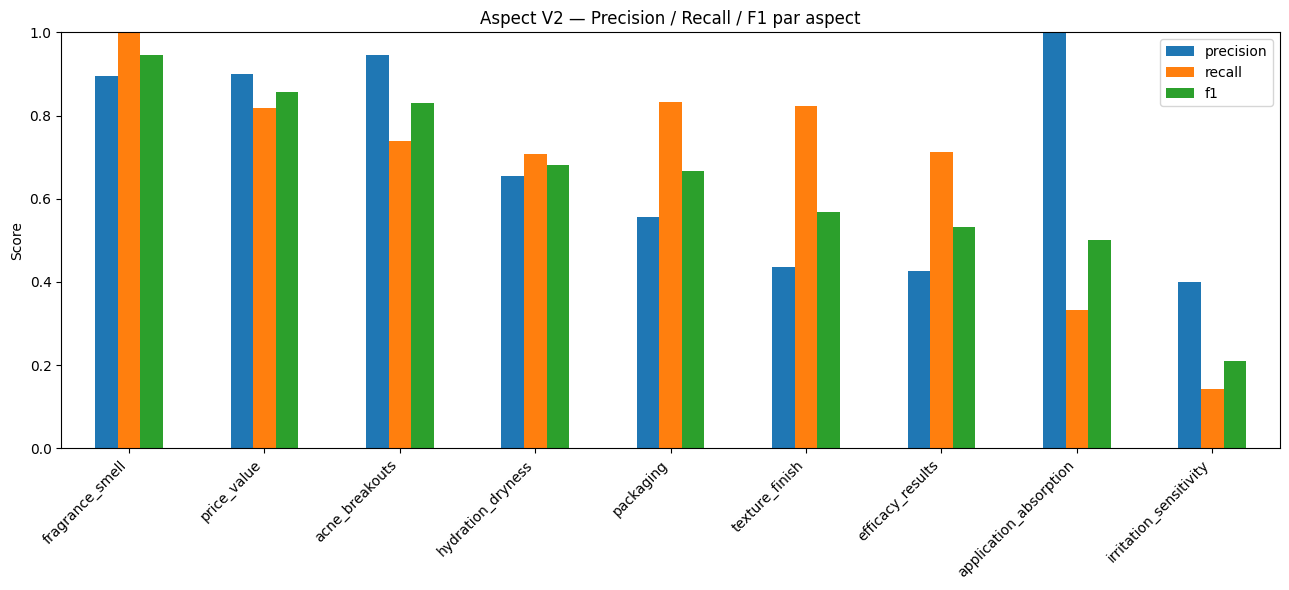

In [15]:
ax = (
    aspect_per_class
    .set_index("aspect_id")[["precision","recall","f1"]]
    .plot(kind="bar", figsize=(13,6))
)
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.set_title("Aspect V2 — Precision / Recall / F1 par aspect")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## A3. Support par aspect

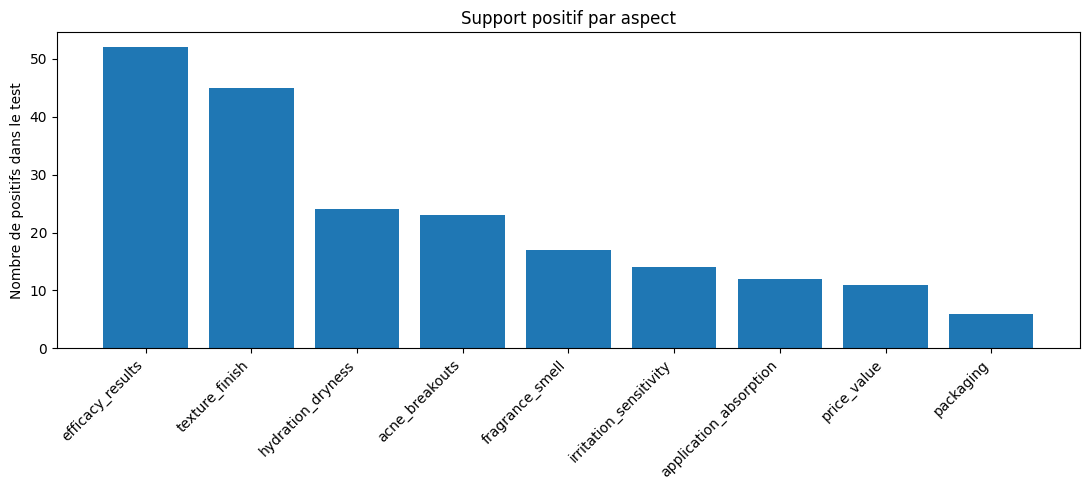

In [16]:
support_df = aspect_per_class.sort_values("support_positive", ascending=False)

plt.figure(figsize=(11,5))
plt.bar(support_df["aspect_id"], support_df["support_positive"])
plt.ylabel("Nombre de positifs dans le test")
plt.title("Support positif par aspect")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## A4. Matrices de confusion par aspect

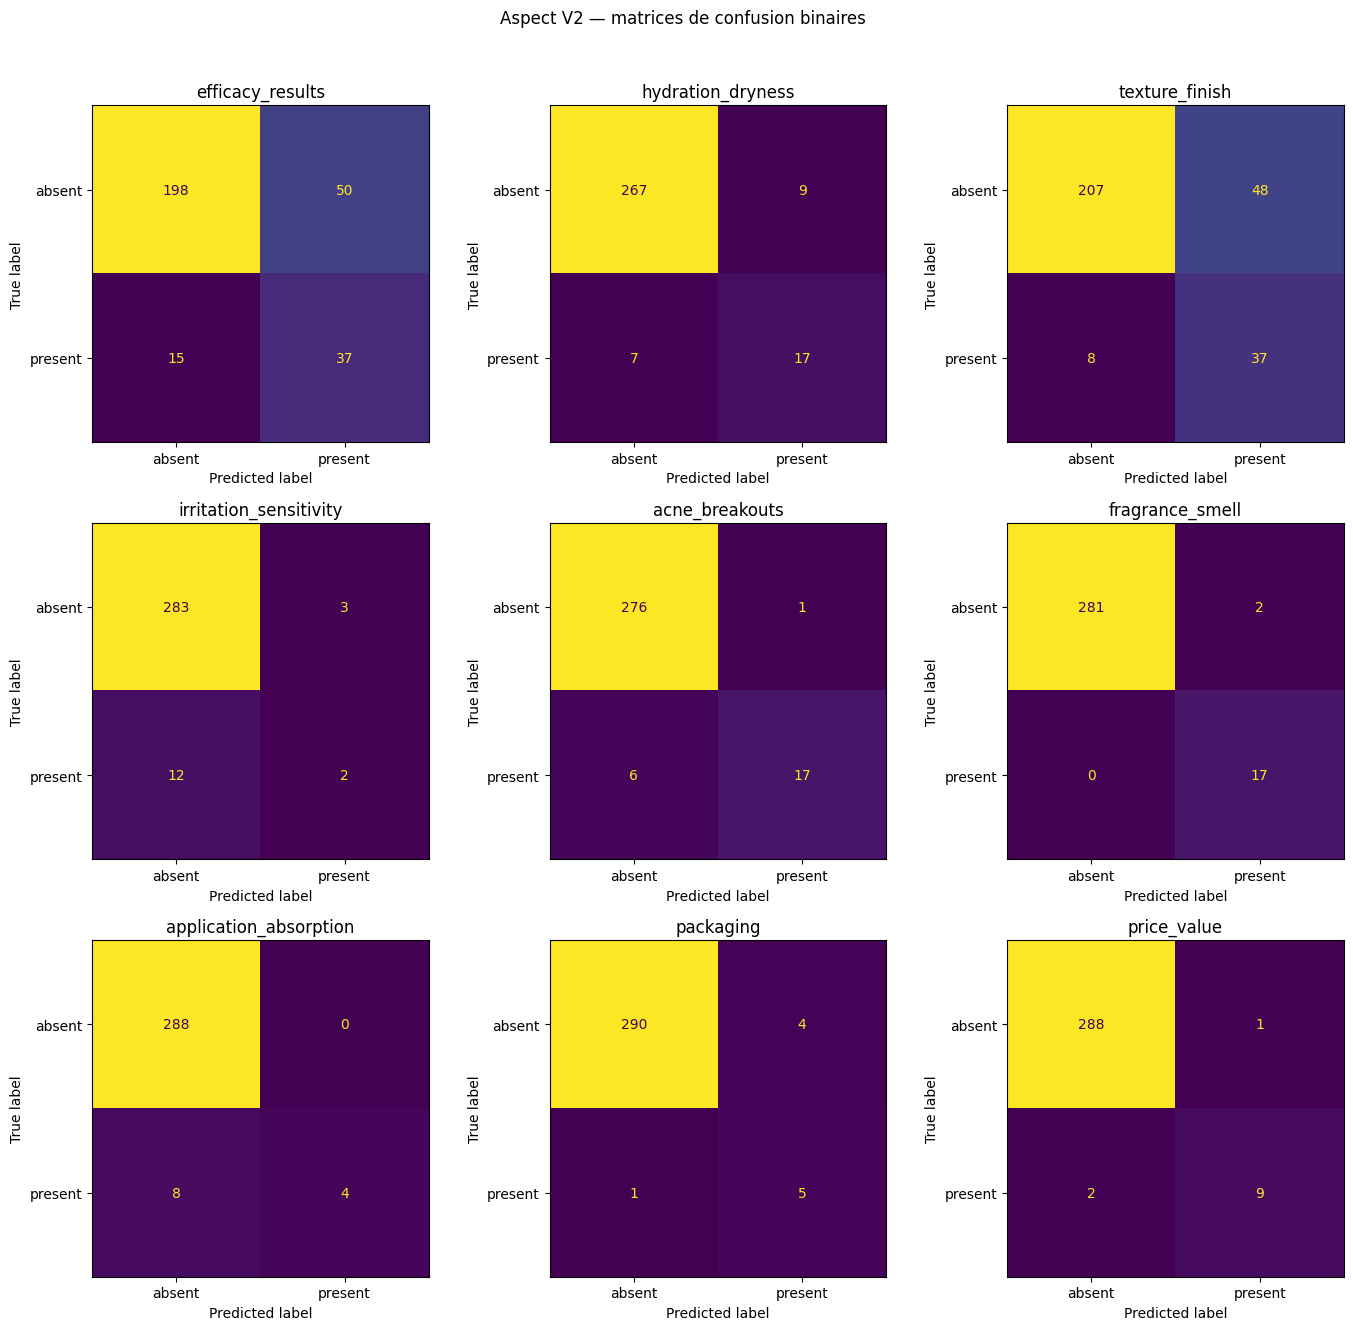

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(14,13))
axes = axes.ravel()

for i, aspect in enumerate(ASPECTS):
    cm = confusion_matrix(
        y_true_aspect[:,i],
        y_pred_aspect[:,i],
        labels=[0,1],
    )
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["absent","present"],
    )
    disp.plot(ax=axes[i], colorbar=False, values_format="d")
    axes[i].set_title(aspect)

plt.suptitle("Aspect V2 — matrices de confusion binaires", y=1.02)
plt.tight_layout()
plt.show()


# B — Sentiment

In [18]:
pair_meta = (
    pairs
    .drop(columns=["review_id","segment_text"], errors="ignore")
    .merge(
        sample[["segment_id","review_id","segment_text"]]
        .drop_duplicates("segment_id"),
        on="segment_id",
        how="left",
        validate="many_to_one",
    )
)

test_reviews = set(test_sample["review_id"].astype(str))
pair_meta["_review_str"] = pair_meta["review_id"].astype(str)
test_sent = pair_meta[pair_meta["_review_str"].isin(test_reviews)].copy()

sent2id = {"negative":0, "neutral":1, "positive":2}
id2sent = {0:"negative", 1:"neutral", 2:"positive"}

test_sent["model_text"] = (
    "[ASPECT] "
    + test_sent["aspect_id"].astype(str)
    + " [TEXT] "
    + test_sent["segment_text"].astype(str)
)

y_true_sent = test_sent["sentiment"].map(sent2id).to_numpy()

print("Paires sentiment test :", len(test_sent))
display(test_sent["sentiment"].value_counts().to_frame("n"))


Paires sentiment test : 204


,n
sentiment,
positive,133
negative,64
neutral,7


In [20]:
sent_tokenizer = AutoTokenizer.from_pretrained(SENT_MODEL_DIR)

sent_model = AutoModelForSequenceClassification.from_pretrained(
    SENT_MODEL_DIR
).to(DEVICE)

sent_model.eval()

texts = test_sent["model_text"].astype(str).tolist()
preds = []

for start in range(0, len(texts), BATCH_SIZE):
    batch_texts = texts[start:start + BATCH_SIZE]

    enc = sent_tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=160,
        return_tensors="pt",
        return_token_type_ids=False,
    )

    enc = {
        k: v.to(DEVICE)
        for k, v in enc.items()
    }

    with torch.no_grad():
        logits = sent_model(**enc).logits

    preds.extend(
        logits.argmax(dim=-1)
        .cpu()
        .numpy()
        .tolist()
    )

y_pred_sent = np.array(preds)

print(
    "Predictions sentiment :",
    len(y_pred_sent)
)

Predictions sentiment : 204


## B1. Métriques globales

In [21]:
sent_accuracy = accuracy_score(y_true_sent, y_pred_sent)
sent_f1_macro = f1_score(
    y_true_sent, y_pred_sent, average="macro", zero_division=0
)
sent_f1_weighted = f1_score(
    y_true_sent, y_pred_sent, average="weighted", zero_division=0
)

sent_global = pd.DataFrame({
    "metric":["accuracy","f1_macro","f1_weighted"],
    "value":[sent_accuracy,sent_f1_macro,sent_f1_weighted],
})

display(sent_global)


,metric,value
0,accuracy,0.813725
1,f1_macro,0.630655
2,f1_weighted,0.818509


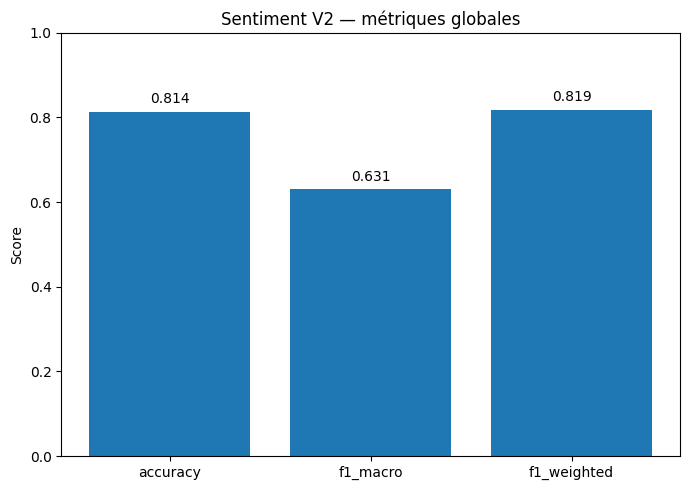

In [22]:
plt.figure(figsize=(7,5))
plt.bar(sent_global["metric"], sent_global["value"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Sentiment V2 — métriques globales")
for i, v in enumerate(sent_global["value"]):
    plt.text(i, v+0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


## B2. Classification report

In [23]:
report = classification_report(
    y_true_sent,
    y_pred_sent,
    labels=[0,1,2],
    target_names=["negative","neutral","positive"],
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T
display(report_df)


,precision,recall,f1-score,support
negative,0.732394,0.812500,0.770370,64.000000
neutral,0.222222,0.285714,0.250000,7.000000
positive,0.903226,0.842105,0.871595,133.000000
accuracy,0.813725,0.813725,0.813725,0.813725
macro avg,0.619281,0.646773,0.630655,204.000000
weighted avg,0.826264,0.813725,0.818509,204.000000


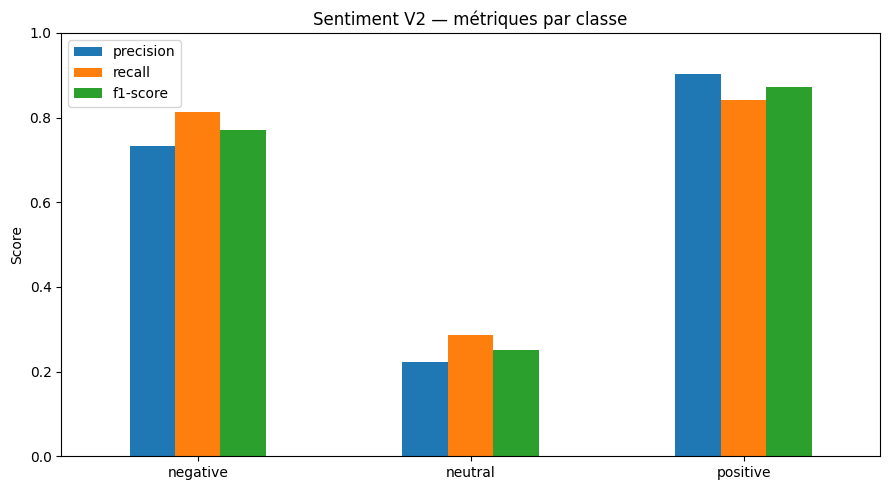

In [24]:
ax = (
    report_df
    .loc[
        ["negative","neutral","positive"],
        ["precision","recall","f1-score"]
    ]
    .plot(kind="bar", figsize=(9,5))
)
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.set_title("Sentiment V2 — métriques par classe")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## B3. Matrice de confusion

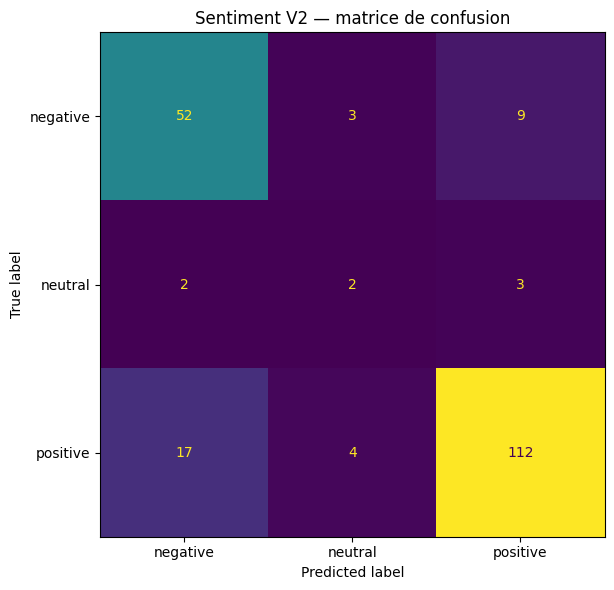

In [25]:
cm_sent = confusion_matrix(y_true_sent, y_pred_sent, labels=[0,1,2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sent,
    display_labels=["negative","neutral","positive"],
)

fig, ax = plt.subplots(figsize=(7,6))
disp.plot(ax=ax, colorbar=False, values_format="d")
plt.title("Sentiment V2 — matrice de confusion")
plt.tight_layout()
plt.show()


# C — V1 vs V2

In [26]:
if COMPARE_ASPECT_CSV is not None:
    comparison_aspect = pd.read_csv(COMPARE_ASPECT_CSV)
else:
    comparison_aspect = pd.DataFrame([
        {
            "version":"V1",
            "precision_micro":0.5455,
            "recall_micro":0.0294,
            "f1_micro":0.0558,
            "precision_macro":0.0606,
            "recall_macro":0.0148,
            "f1_macro":0.0238,
            "exact_match":0.4267,
        },
        {
            "version":"V2",
            "precision_micro":p_micro,
            "recall_micro":r_micro,
            "f1_micro":f1_micro,
            "precision_macro":p_macro,
            "recall_macro":r_macro,
            "f1_macro":f1_macro,
            "exact_match":exact_match,
        },
    ])

display(comparison_aspect)


,version,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,exact_match
0,V1,0.545500,0.029400,0.055800,0.060600,0.01480,0.023800,0.426700
1,V2,0.551331,0.710784,0.620985,0.689907,0.67877,0.643295,0.563333


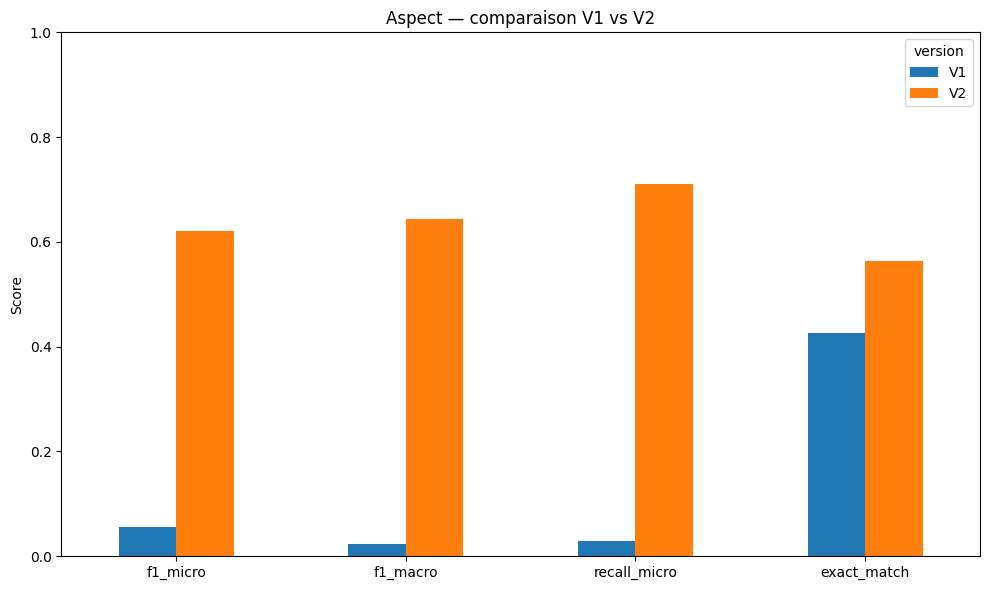

In [27]:
ax = (
    comparison_aspect
    .set_index("version")[["f1_micro","f1_macro","recall_micro","exact_match"]]
    .T
    .plot(kind="bar", figsize=(10,6))
)
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.set_title("Aspect — comparaison V1 vs V2")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [28]:
if COMPARE_SENT_CSV is not None:
    comparison_sentiment = pd.read_csv(COMPARE_SENT_CSV)
else:
    comparison_sentiment = pd.DataFrame([
        {
            "version":"V1",
            "accuracy":0.7990,
            "f1_macro":0.5323,
            "f1_weighted":0.7898,
        },
        {
            "version":"V2",
            "accuracy":sent_accuracy,
            "f1_macro":sent_f1_macro,
            "f1_weighted":sent_f1_weighted,
        },
    ])

display(comparison_sentiment)


,version,accuracy,f1_macro,f1_weighted
0,V1,0.799000,0.532300,0.789800
1,V2,0.813725,0.630655,0.818509


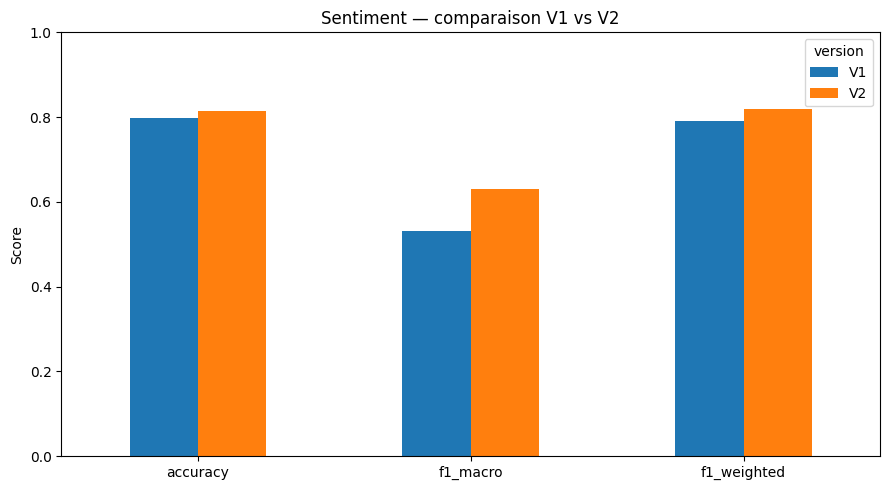

In [29]:
ax = (
    comparison_sentiment
    .set_index("version")[["accuracy","f1_macro","f1_weighted"]]
    .T
    .plot(kind="bar", figsize=(9,5))
)
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.set_title("Sentiment — comparaison V1 vs V2")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# D — Erreurs de sentiment

In [30]:
error_df = test_sent[
    ["segment_id","aspect_id","segment_text","sentiment"]
].copy()

error_df["pred_sentiment"] = [id2sent[x] for x in y_pred_sent]
error_df["is_error"] = error_df["sentiment"] != error_df["pred_sentiment"]

print(
    "Erreurs sentiment :",
    int(error_df["is_error"].sum()),
    "/",
    len(error_df),
)

display(error_df[error_df["is_error"]].head(20))


Erreurs sentiment : 38 / 204


,segment_id,aspect_id,segment_text,sentiment,pred_sentiment,is_error
21,reviews_0-250::39255::s6,texture_finish,I used BE Mineral Veil over it and was ready t...,positive,negative,True
35,reviews_0-250::557077::s5,acne_breakouts,I haven’t experienced any breakouts or clogged...,positive,negative,True
47,reviews_1250-end::30750::s1,acne_breakouts,I was looking for something to help with occas...,positive,negative,True
67,reviews_500-750::9673::s6,price_value,"It is very pricey, but still in my range and I...",positive,negative,True
95,reviews_0-250::17688::s2,irritation_sensitivity,"It was too gentle, but if you have sensitive s...",positive,negative,True
118,reviews_250-500::152142::s0,irritation_sensitivity,THIS HELPS WITH BREAKOUTS....IT IS STRONG AND ...,negative,positive,True
155,reviews_250-500::16030::s6,texture_finish,"The milk is pretty thick by itself, warm it up...",neutral,positive,True
253,reviews_0-250::94951::s2,irritation_sensitivity,"Second- yes, it can be tingly.",negative,positive,True
275,reviews_250-500::135132::s0,fragrance_smell,"I really enjoy this product, however the scent...",negative,positive,True
288,reviews_0-250::201065::s5,price_value,It’s on the pricey side.,negative,neutral,True


In [31]:
error_pairs = (
    error_df[error_df["is_error"]]
    .groupby(["sentiment","pred_sentiment"])
    .size()
    .reset_index(name="n_errors")
    .sort_values("n_errors", ascending=False)
)

display(error_pairs)


,sentiment,pred_sentiment,n_errors
4,positive,negative,17
1,negative,positive,9
5,positive,neutral,4
0,negative,neutral,3
3,neutral,positive,3
2,neutral,negative,2


# E — Vitesse locale

In [33]:
bench_texts = test_sample["segment_text"].astype(str).tolist()[:200]

enc = aspect_tokenizer(
    bench_texts,
    padding=True,
    truncation=True,
    max_length=160,
    return_tensors="pt",
    return_token_type_ids=False,
)
enc = {k:v.to(DEVICE) for k,v in enc.items()}

if DEVICE == "cuda":
    torch.cuda.synchronize()

t0 = time.perf_counter()

with torch.no_grad():
    _ = aspect_model(**enc)

if DEVICE == "cuda":
    torch.cuda.synchronize()

elapsed = time.perf_counter() - t0

speed_df = pd.DataFrame({
    "metric":[
        "segments",
        "seconds",
        "ms_per_segment",
        "segments_per_second",
    ],
    "value":[
        len(bench_texts),
        elapsed,
        1000*elapsed/len(bench_texts),
        len(bench_texts)/elapsed,
    ],
})

display(speed_df)


,metric,value
0,segments,200.00000
1,seconds,9.17848
2,ms_per_segment,45.89240
3,segments_per_second,21.79010


# Conclusion

La V2 améliore nettement la détection des aspects par rapport à la V1. Le sentiment reste plus fragile, surtout pour la classe neutre et certaines phrases contrastives.